# HW9 - Tiny MMDiT-Style Conditioning

Question: how do text tokens and image tokens interact?


> CPU smoke run: this notebook is designed to execute quickly on CPU to verify mechanics, tensor shapes, plotting, and sampler logic. Generated samples may look like noise because the default training loop is intentionally tiny. Treat noisy samples as undertraining, not as evidence that the method is wrong. For meaningful visual quality, run longer on a GPU by increasing training steps, batch size, diffusion steps, and model width.


Sources:

- Qwen-Image Technical Report: https://arxiv.org/abs/2508.02324
- DiT: https://arxiv.org/abs/2212.09748


In [1]:
import math
import random
from pathlib import Path
from io import BytesIO

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from IPython.display import Image, display

torch.manual_seed(7)
random.seed(7)
torch.set_num_threads(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def show_plot():
    fig = plt.gcf()
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    display(Image(data=buf.getvalue()))
    plt.close(fig)


device: cpu


In [2]:
COLORS = {
    "red": torch.tensor([1.0, 0.08, 0.08]),
    "green": torch.tensor([0.08, 0.80, 0.20]),
    "blue": torch.tensor([0.08, 0.25, 1.0]),
    "yellow": torch.tensor([1.0, 0.88, 0.08]),
}
SHAPES = ["circle", "square", "triangle"]


def draw_triangle(xx, yy, scale):
    # Upright triangle mask in normalized coordinates.
    top = yy > -scale
    left = yy < 2 * scale * (xx + scale)
    right = yy < -2 * scale * (xx - scale)
    return top & left & right & (yy < scale)


def make_shape_batch(batch=64, size=32, with_text=True):
    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, size),
        torch.linspace(-1, 1, size),
        indexing="ij",
    )
    images, captions = [], []
    for _ in range(batch):
        color_name = random.choice(list(COLORS))
        shape_name = random.choice(SHAPES)
        color = COLORS[color_name][:, None]
        scale = random.uniform(0.42, 0.72)
        img = torch.zeros(3, size, size)
        if shape_name == "circle":
            mask = xx.square() + yy.square() < scale**2
        elif shape_name == "square":
            mask = (xx.abs() < scale) & (yy.abs() < scale)
        else:
            mask = draw_triangle(xx, yy, scale)
        img[:, mask] = color
        images.append(img)
        captions.append(f"{color_name} {shape_name}")
    images = torch.stack(images)
    return (images, captions) if with_text else images


def show_images(images, titles=None, n=16, size=2.0):
    images = images.detach().cpu().clamp(0, 1)
    n = min(n, images.shape[0])
    cols = min(8, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * size, rows * size))
    axes = [axes] if n == 1 else axes.reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(images[i].permute(1, 2, 0))
            if titles:
                ax.set_title(titles[i], fontsize=8)
    plt.tight_layout()
    show_plot()


In [3]:
VOCAB = ["<pad>", "<null>", "red", "green", "blue", "yellow", "circle", "square", "triangle"]
stoi = {tok: i for i, tok in enumerate(VOCAB)}
itos = {i: tok for tok, i in stoi.items()}


def tokenize(captions, max_len=2, drop_prob=0.0):
    ids = []
    for cap in captions:
        if random.random() < drop_prob:
            words = ["<null>"]
        else:
            words = cap.split()
        row = [stoi.get(w, 0) for w in words[:max_len]]
        row += [0] * (max_len - len(row))
        ids.append(row)
    return torch.tensor(ids, dtype=torch.long, device=device)


In [4]:
T = 8
betas = torch.linspace(1e-4, 0.05, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def q_sample(x0, t, eps=None):
    if eps is None:
        eps = torch.randn_like(x0)
    ab = alpha_bars[t].view(-1, *([1] * (x0.ndim - 1)))
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps, eps


@torch.no_grad()
def ddpm_sample(model, shape, cond=None, guidance_scale=None, cond_fn=None):
    x = torch.randn(shape, device=device)
    for ti in reversed(range(T)):
        t = torch.full((shape[0],), ti, device=device, dtype=torch.long)
        if guidance_scale is None:
            pred_eps = model(x, t) if cond is None else model(x, t, cond)
        else:
            eps_uncond = cond_fn(x, t, None)
            eps_cond = cond_fn(x, t, cond)
            pred_eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        beta, alpha, ab = betas[ti], alphas[ti], alpha_bars[ti]
        mean = (1 / alpha.sqrt()) * (x - beta / (1 - ab).sqrt() * pred_eps)
        x = mean if ti == 0 else mean + beta.sqrt() * torch.randn_like(x)
    return x


In [5]:
PATCH = 4


def patchify(x, patch=PATCH):
    b, c, h, w = x.shape
    x = x.reshape(b, c, h // patch, patch, w // patch, patch)
    x = x.permute(0, 2, 4, 3, 5, 1)
    return x.reshape(b, (h // patch) * (w // patch), patch * patch * c)


def unpatchify(tokens, patch=PATCH, channels=3, size=32):
    b, n, d = tokens.shape
    side = size // patch
    x = tokens.reshape(b, side, side, patch, patch, channels)
    x = x.permute(0, 5, 1, 3, 2, 4)
    return x.reshape(b, channels, size, size)


In [6]:
class TinyMMDiT(nn.Module):
    def __init__(self, token_dim=48, model_dim=32, depth=1):
        super().__init__()
        self.img_in = nn.Linear(token_dim, model_dim)
        self.img_out = nn.Linear(model_dim, token_dim)
        self.text = nn.Embedding(len(VOCAB), model_dim)
        self.time = nn.Linear(1, model_dim)
        self.pos_img = nn.Parameter(torch.randn(1, 64, model_dim) * 0.02)
        self.pos_txt = nn.Parameter(torch.randn(1, 2, model_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(model_dim, nhead=4, dim_feedforward=64, batch_first=True, activation="gelu")
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)

    def forward(self, x, t, token_ids):
        img = self.img_in(patchify(x)) + self.pos_img
        txt = self.text(token_ids) + self.pos_txt
        time = self.time((t.float() / (T - 1))[:, None])[:, None, :]
        tokens = torch.cat([txt + time, img + time], dim=1)
        out = self.blocks(tokens)
        img_out = out[:, txt.shape[1]:]
        return unpatchify(self.img_out(img_out))


model = TinyMMDiT().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-3)


In [7]:
x0, caps = make_shape_batch(4)
tok = tokenize(caps)
print("caption tokens:", tok.shape)
print("image latent tokens:", patchify(x0).shape)

for step in range(5):
    x0, caps = make_shape_batch(8)
    x0 = x0.to(device)
    tok = tokenize(caps)
    t = torch.randint(0, T, (x0.shape[0],), device=device)
    xt, eps = q_sample(x0, t)
    pred = model(xt, t, tok)
    loss = F.mse_loss(pred, eps)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 5 == 0:
        print(step, round(loss.item(), 4))


caption tokens: torch.Size([4, 2])
image latent tokens: torch.Size([4, 64, 48])
0 1.3616


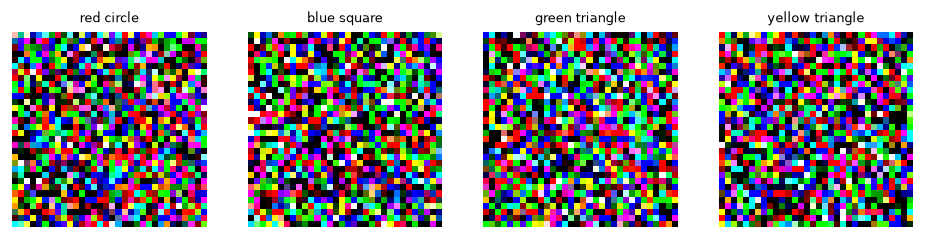

In [8]:
prompts = ["red circle", "blue square", "green triangle", "yellow triangle"]
samples = ddpm_sample(model, (len(prompts), 3, 32, 32), cond=tokenize(prompts)).cpu()
show_images(samples, prompts, n=len(prompts))


## Interview Takeaway

Pooled text conditioning compresses the whole prompt into one vector. MMDiT-style token mixing keeps text tokens and image tokens in the same reasoning space, which is closer to Qwen-like multimodal conditioning.
